In [4]:
%matplotlib inline
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import seaborn as sns
import numpy as np
import warnings

In [5]:
target_column = "health_condition"

In [6]:
df = pd.read_csv("../data/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [7]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


Check skewness

In [8]:
df.skew(numeric_only=True)

id                    -9.610032e-17
sleep_duration        -8.232339e-03
heart_rate             4.382013e-04
bmi                    2.463976e-02
calorie_expenditure   -1.839400e-01
step_count            -1.802384e-01
exercise_duration     -3.746098e-01
water_intake           1.099603e-01
dtype: float64

Show missing counts

In [9]:
df.isna().sum().sort_values(ascending=False)

stress_level               82811
sleep_duration             75999
sleep_quality              58331
calorie_expenditure        52853
water_intake               43477
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
step_count                 13916
bmi                        13898
heart_rate                  7833
diet_type                   6901
exercise_duration           6901
id                             0
health_condition               0
dtype: int64

Show missing percentage

In [10]:
df.isna().sum().sort_values(ascending=False)/len(df)*100

stress_level               12.000064
sleep_duration             11.012943
sleep_quality               8.452690
calorie_expenditure         7.658878
water_intake                6.300211
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
step_count                  2.016554
bmi                         2.013946
heart_rate                  1.135073
diet_type                   1.000017
exercise_duration           1.000017
id                          0.000000
health_condition            0.000000
dtype: float64

In [11]:
def show_missing_values(data, palette="viridis"):
    missing_values = data.isna().sum().sort_values(ascending=False)
    sns.barplot(x=missing_values.values, y=missing_values.index,palette=palette)

Show missing graph

C:\Users\abhin\AppData\Local\Temp\ipykernel_12464\737228090.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.values, y=missing_values.index,palette=palette)


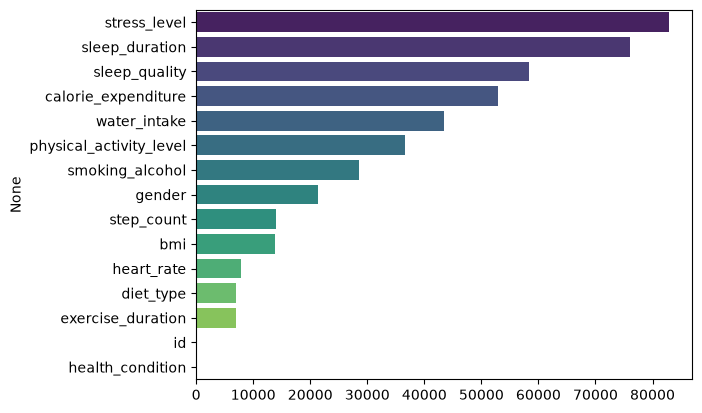

In [12]:
show_missing_values(df)

Check target counts

<Axes: xlabel='health_condition', ylabel='count'>

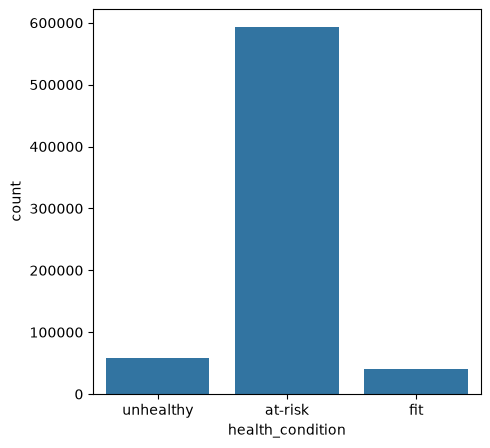

In [13]:
fig,axs = plt.subplots(figsize=(5,5),ncols=1)

sns.countplot(df,x=target_column,ax=axs)

*Most at risk of health? Very few people are unhealthy or fully fit. Also heavy class imbalance*

Check categorical target correlations

<Axes: xlabel='gender', ylabel='count'>

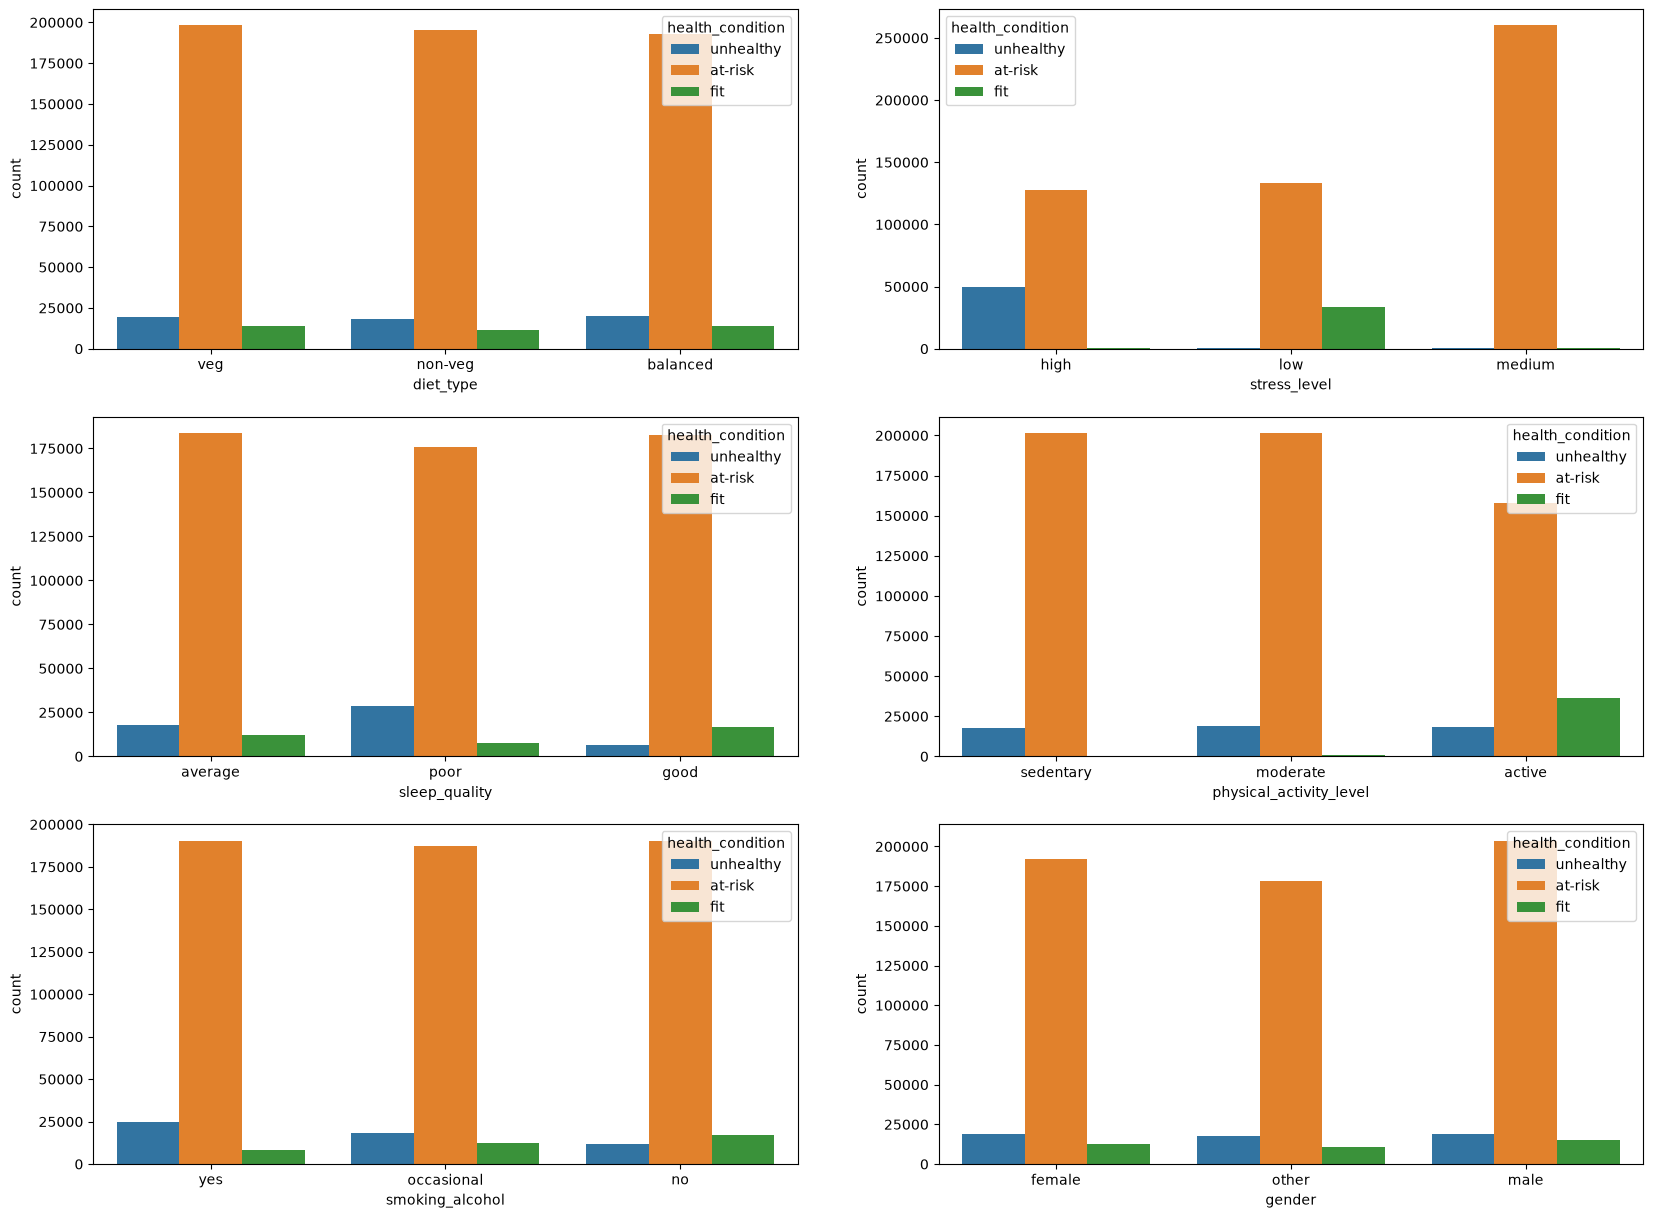

In [14]:
fig,axs = plt.subplots(figsize=(20,15),nrows=3, ncols=2)
sns.countplot(df, x="diet_type",hue=target_column,ax=axs[0][0])
sns.countplot(df, x="stress_level",hue=target_column,ax=axs[0][1])
sns.countplot(df, x="sleep_quality",hue=target_column,ax=axs[1][0])
sns.countplot(df, x="physical_activity_level",hue=target_column,ax=axs[1][1])
sns.countplot(df, x="smoking_alcohol",hue=target_column,ax=axs[2][0])
sns.countplot(df, x="gender",hue=target_column,ax=axs[2][1])

1. No clear patterns for veg type
2. Unhealthy students likely have high stress. Fit students likely have low stress. Student with medium stress almost always is at-risk.
3. Students with poor sleep quality have higher chance of being unhealthy. Students with good sleep quality have low chance of being unhealthy.
4. Fit students almost always show active exercise. Likewise, active students are less likely to be at risk.
5. Slight correlations from smoking_alcohol, although not as strong as other categories.
6. No clear correlations for gender.

Show numerical target correlations

<Axes: xlabel='water_intake'>

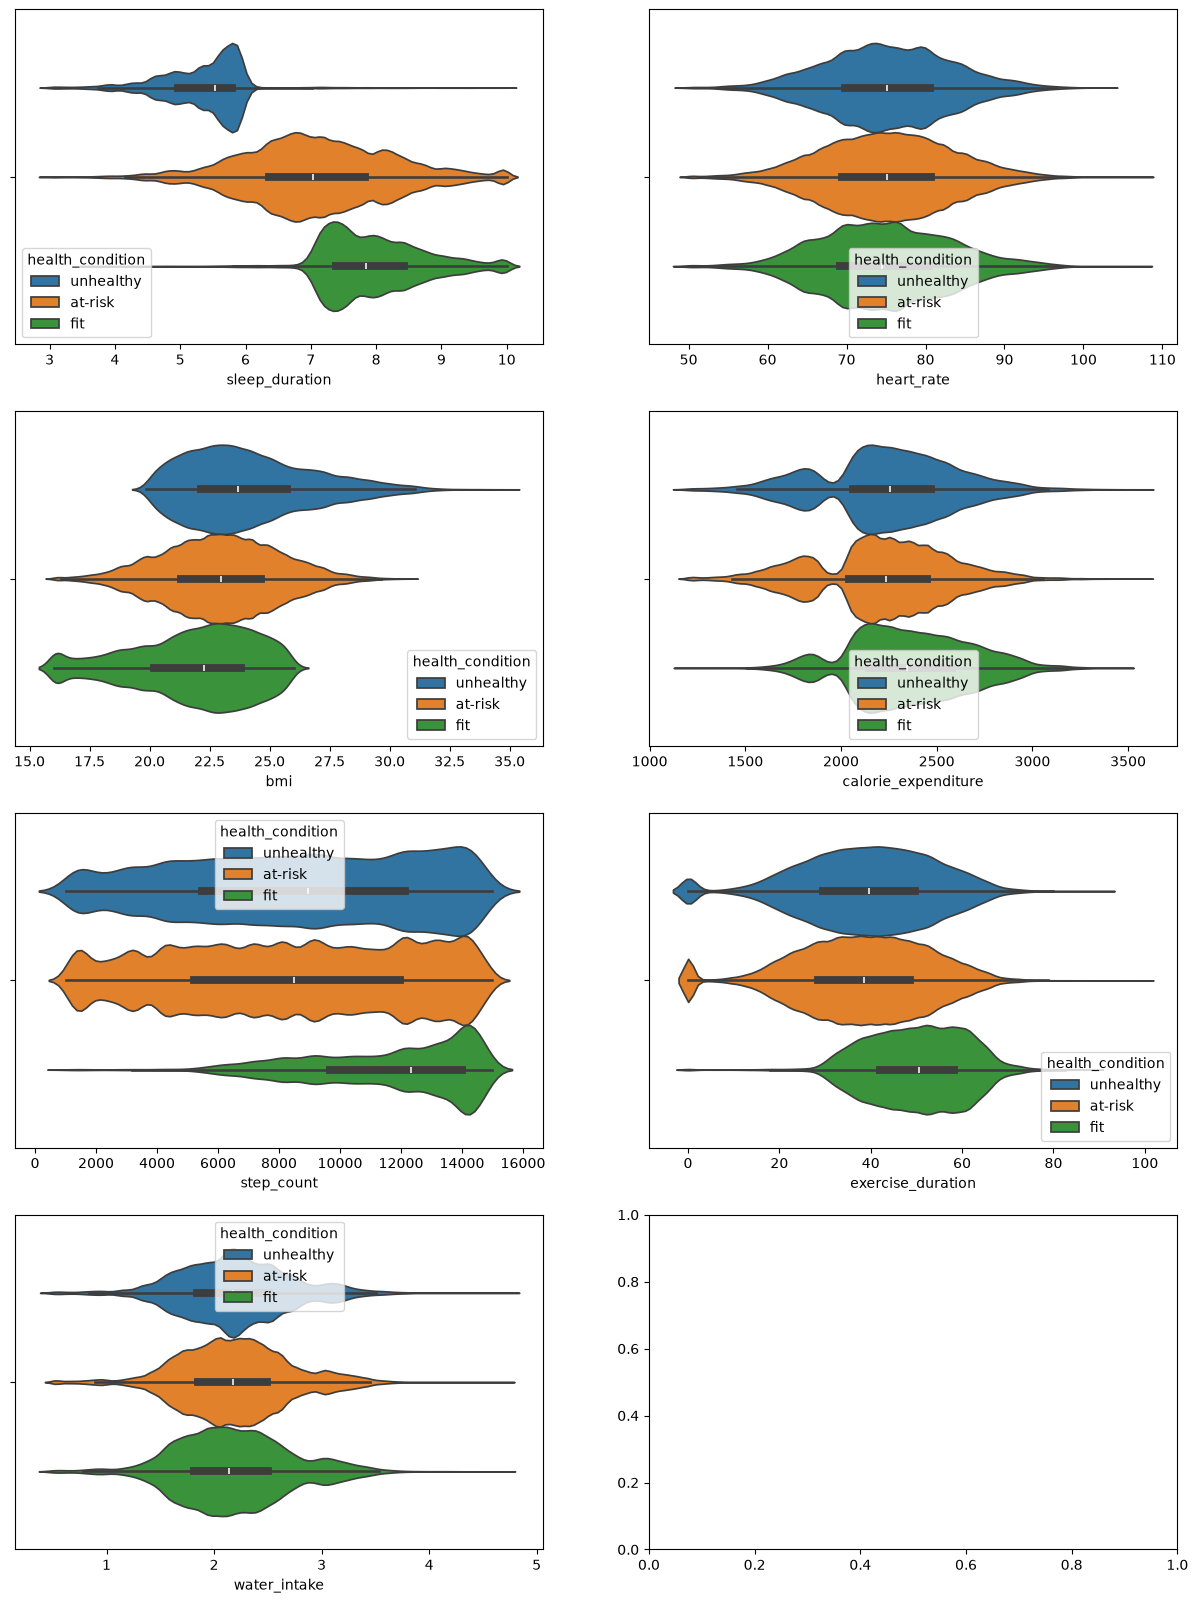

In [15]:
fig, axs = plt.subplots(figsize=(15,20),nrows=4, ncols=2)

sns.violinplot(df, x="sleep_duration",hue=target_column,ax=axs[0][0])
sns.violinplot(df, x="heart_rate",hue=target_column,ax=axs[0][1])
sns.violinplot(df, x="bmi",hue=target_column,ax=axs[1][0])
sns.violinplot(df, x="calorie_expenditure",hue=target_column,ax=axs[1][1])
sns.violinplot(df, x="step_count",hue=target_column,ax=axs[2][0])
sns.violinplot(df, x="exercise_duration",hue=target_column,ax=axs[2][1])
sns.violinplot(df, x="water_intake",hue=target_column,ax=axs[3][0])

1. Sleep duration has a significant effect on the health of a student. Outliers are persistent.
2. Heart rate doesn't seem to have an effect on the student health
3. Students with bmi under 18 are never unhealthy. Fit students always have bmi under 27. Students with higher bmi tend to be at risk or unhealthy.
4. Fit students on average show higher calorie expenditure. Although this pattern doesn't hold for unhealthy vs at-risk students. Odd low frequency plateau exists?
5. Fit students have larger step counts on average. Outliers are persistent.
6. Fit students are likely to exercise longer. Outliers are persistent.
7. No clear effect from water intake.

Show histograms of numerical features

<Axes: xlabel='water_intake', ylabel='Count'>

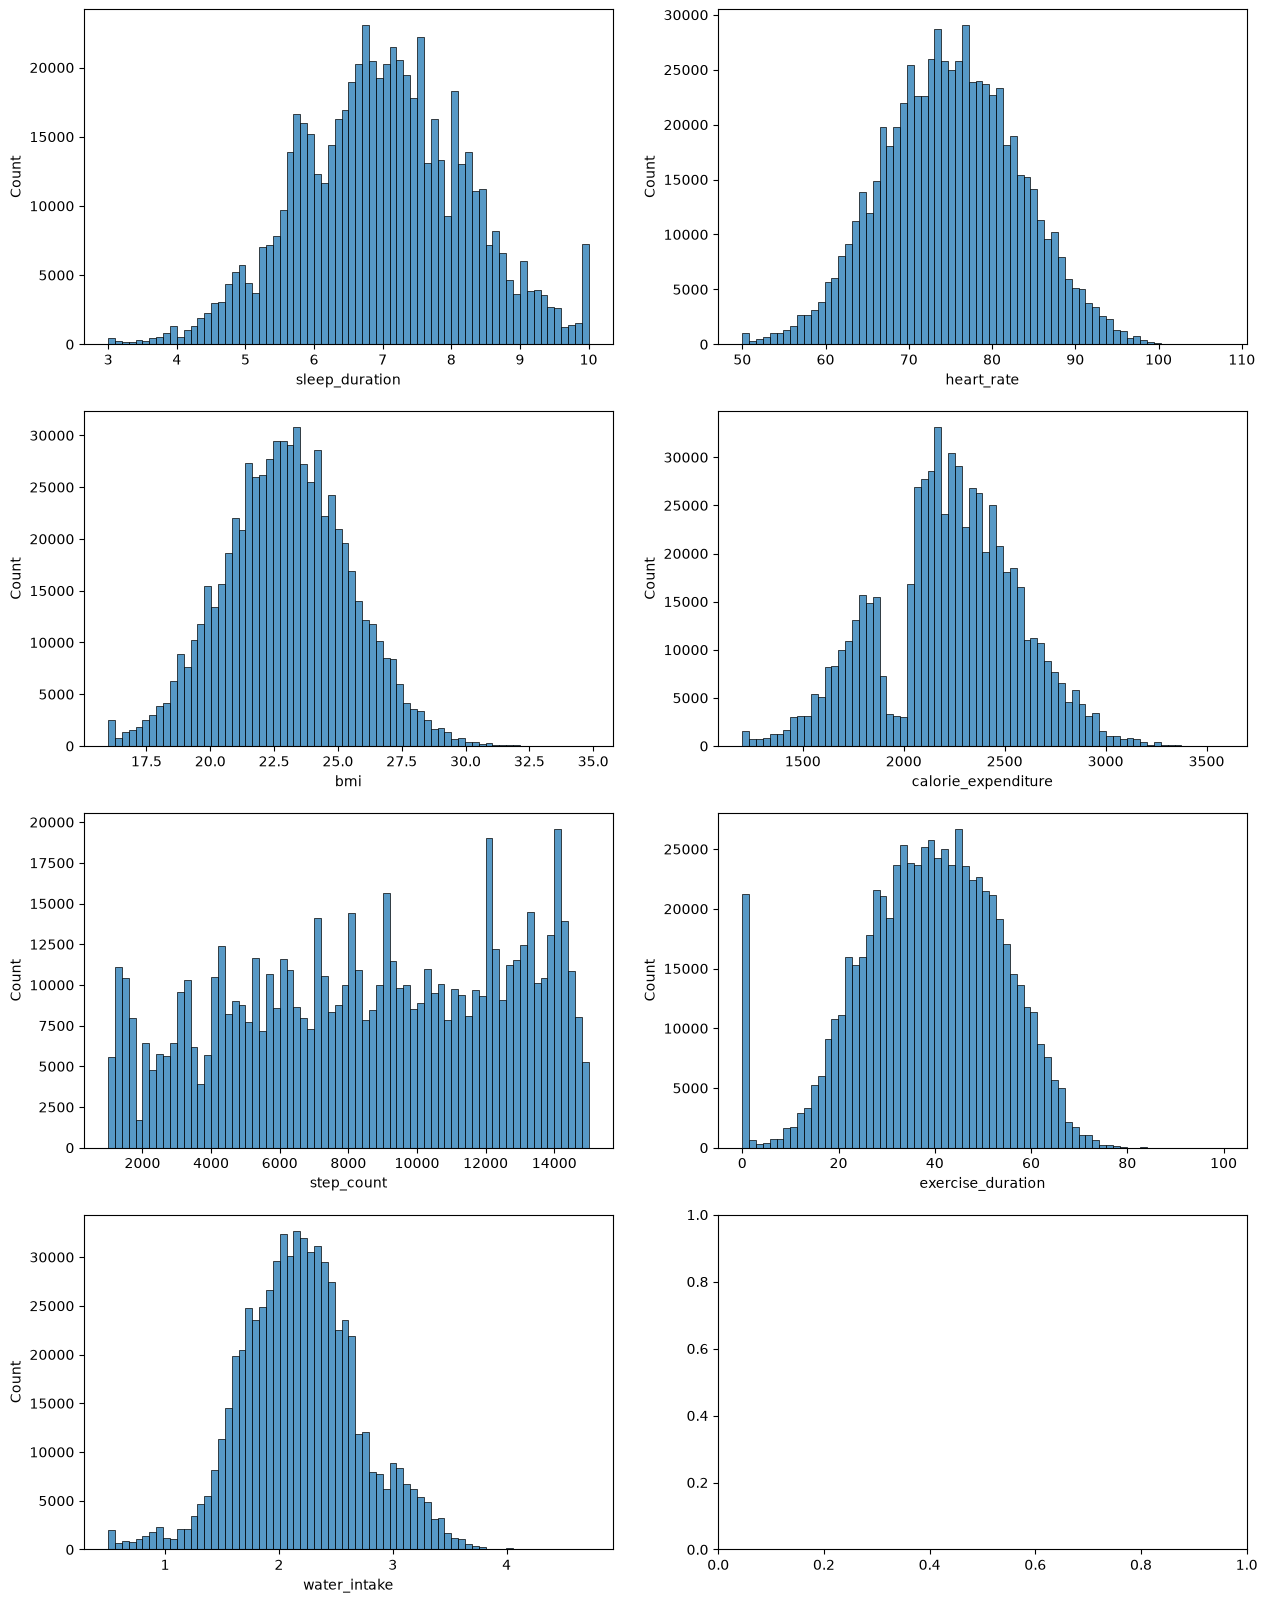

In [16]:
fig, axs = plt.subplots(figsize=(15,20),nrows=4, ncols=2)

sns.histplot(df, x="sleep_duration",ax=axs[0][0],bins=70)
sns.histplot(df, x="heart_rate",ax=axs[0][1],bins=70)
sns.histplot(df, x="bmi",ax=axs[1][0],bins=70)
sns.histplot(df, x="calorie_expenditure",ax=axs[1][1],bins=70)
sns.histplot(df, x="step_count",ax=axs[2][0],bins=70)
sns.histplot(df, x="exercise_duration",ax=axs[2][1],bins=70)
sns.histplot(df, x="water_intake",ax=axs[3][0],bins=70)

**Check patterns across non-target numerical features**

<Axes: xlabel='bmi', ylabel='water_intake'>

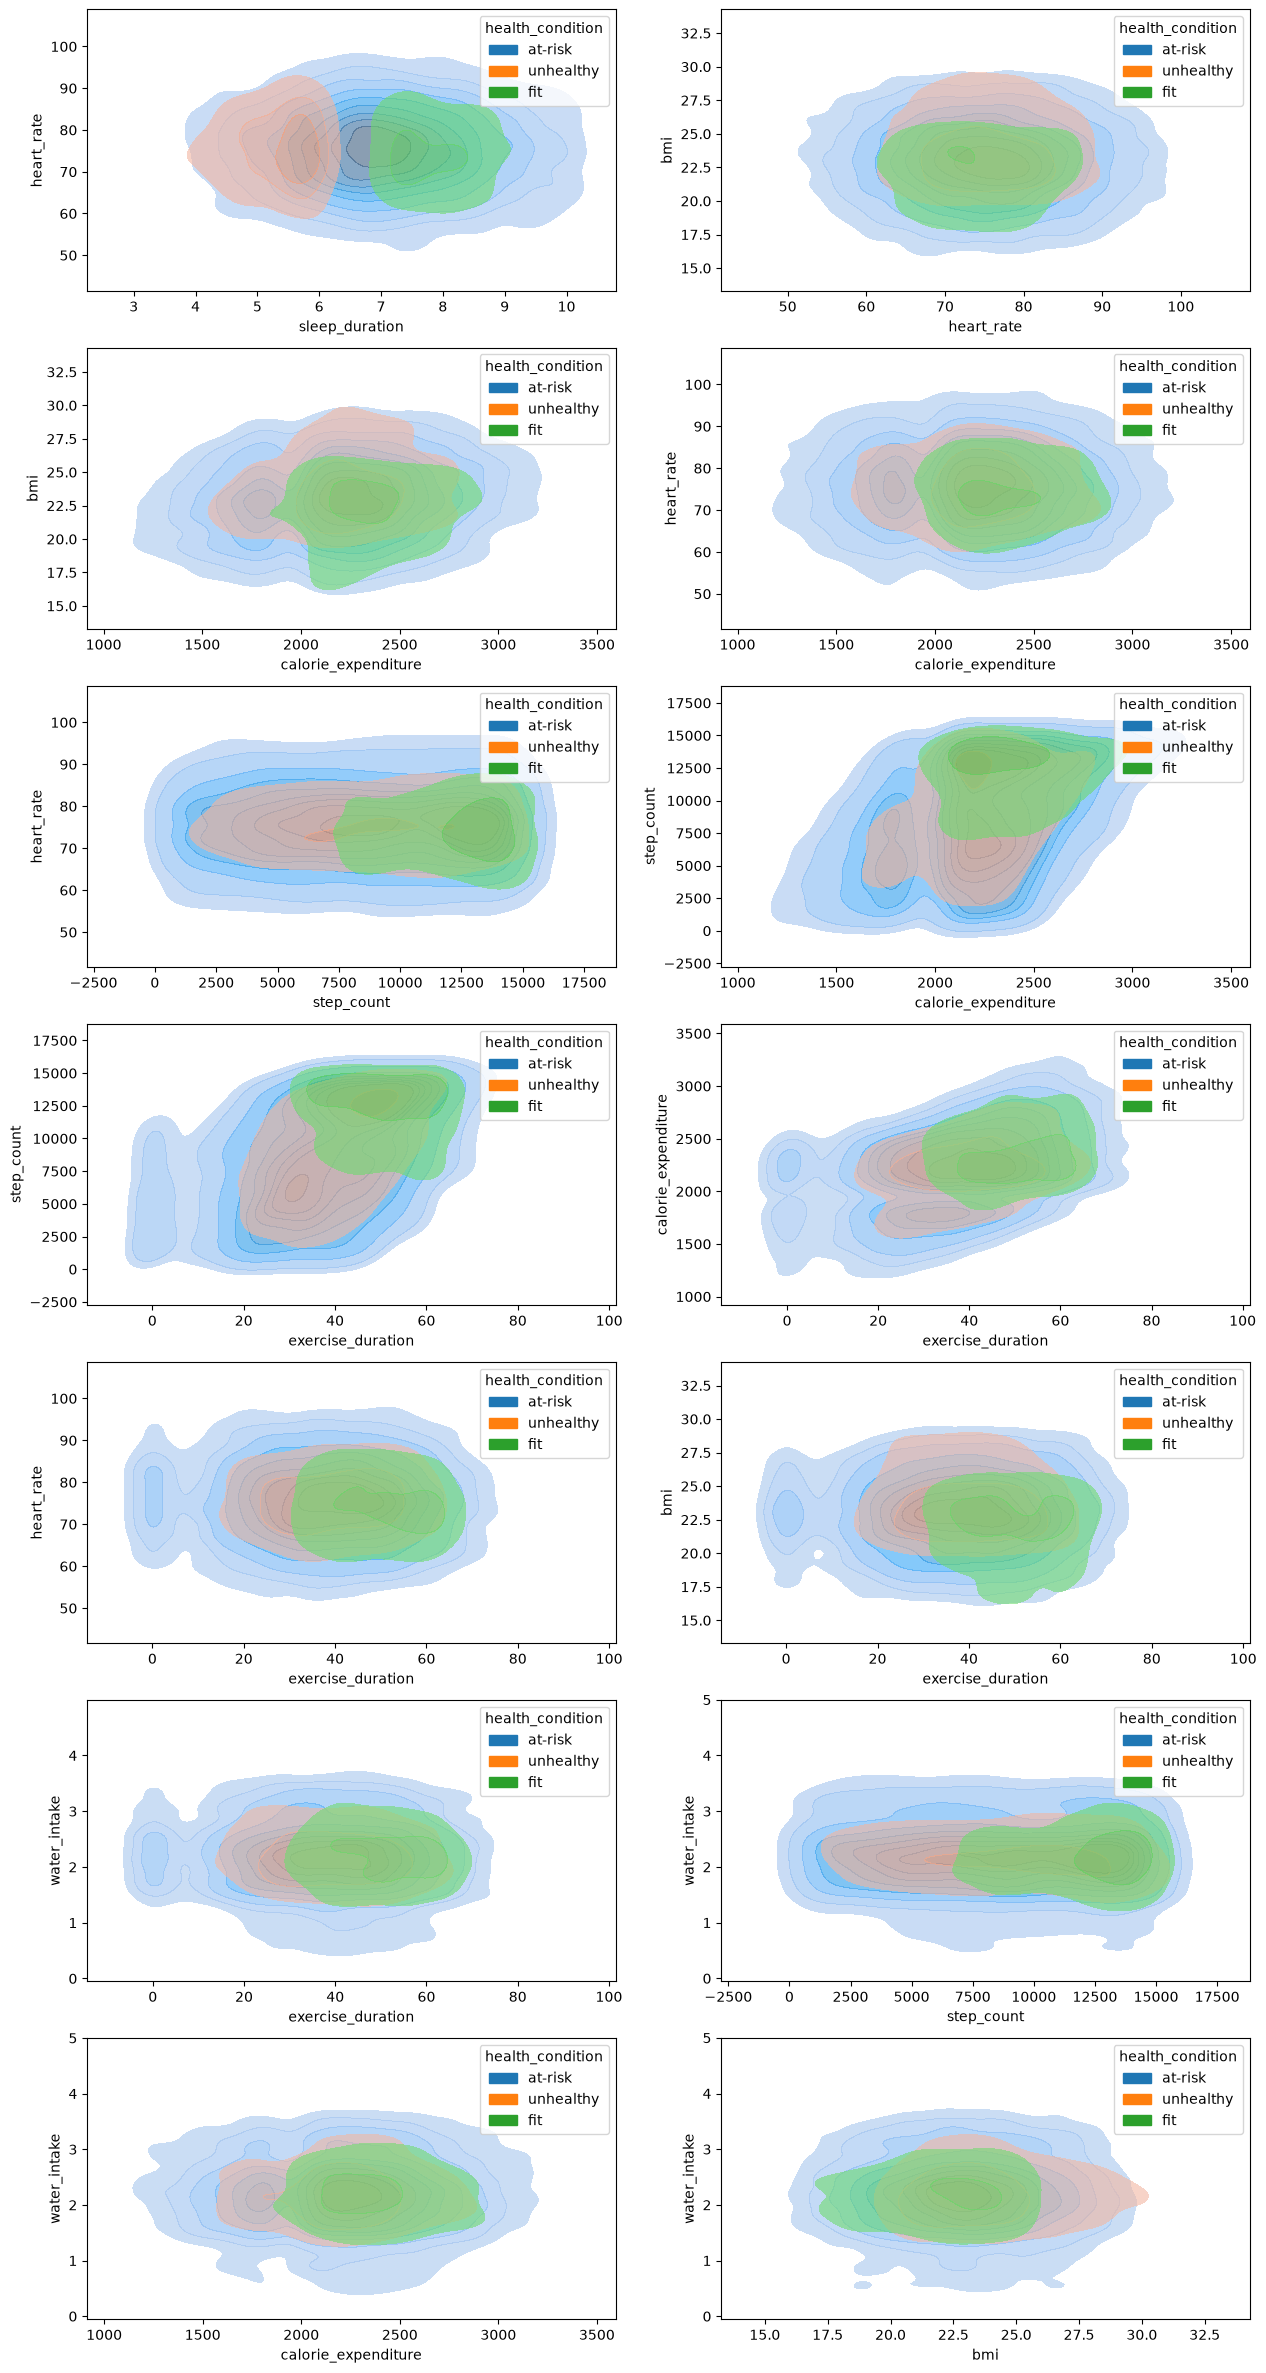

In [17]:
fig, axs = plt.subplots(figsize=(15,30),nrows=7, ncols=2)

ddf = df.sample(n=10000, random_state=42) # Sample 10000 rows

sns.kdeplot(ddf,x="sleep_duration",y="heart_rate",hue=target_column,ax=axs[0][0],fill=True,alpha=0.6,common_norm=True)
sns.kdeplot(ddf,x="heart_rate",y="bmi",hue=target_column,ax=axs[0][1],fill=True,alpha=0.6,common_norm=True)

sns.kdeplot(ddf,x="calorie_expenditure",y="bmi",hue=target_column,ax=axs[1][0],fill=True,alpha=0.6,common_norm=True)
sns.kdeplot(ddf,x="calorie_expenditure",y="heart_rate",hue=target_column,ax=axs[1][1],fill=True,alpha=0.6,common_norm=True)

sns.kdeplot(ddf,x="step_count",y="heart_rate",hue=target_column,ax=axs[2][0],fill=True,alpha=0.6,common_norm=True)
sns.kdeplot(ddf,x="calorie_expenditure",y="step_count",hue=target_column,ax=axs[2][1],fill=True,alpha=0.6,common_norm=True)

sns.kdeplot(ddf,x="exercise_duration",y="step_count",hue=target_column,ax=axs[3][0],fill=True,alpha=0.6,common_norm=True)
sns.kdeplot(ddf,x="exercise_duration",y="calorie_expenditure",hue=target_column,ax=axs[3][1],fill=True,alpha=0.6,common_norm=True)

sns.kdeplot(ddf,x="exercise_duration",y="heart_rate",hue=target_column,ax=axs[4][0],fill=True,alpha=0.6,common_norm=True)
sns.kdeplot(ddf,x="exercise_duration",y="bmi",hue=target_column,ax=axs[4][1],fill=True,alpha=0.6,common_norm=True)

sns.kdeplot(ddf,x="exercise_duration",y="water_intake",hue=target_column,ax=axs[5][0],fill=True,alpha=0.6,common_norm=True)
sns.kdeplot(ddf,x="step_count",y="water_intake",hue=target_column,ax=axs[5][1],fill=True,alpha=0.6,common_norm=True)

sns.kdeplot(ddf,x="calorie_expenditure",y="water_intake",hue=target_column,ax=axs[6][0],fill=True,alpha=0.6,common_norm=True)
sns.kdeplot(ddf,x="bmi",y="water_intake",hue=target_column,ax=axs[6][1],fill=True,alpha=0.6,common_norm=True)

1. Step count and calorie expenditure are positively correlated.
2. Step count and exercise duration are positively correlated.
3. Calorie expenditure and exercise duration are positively correlated.

**Check patterns across numerical categorical features**

<Axes: xlabel='exercise_duration', ylabel='gender'>

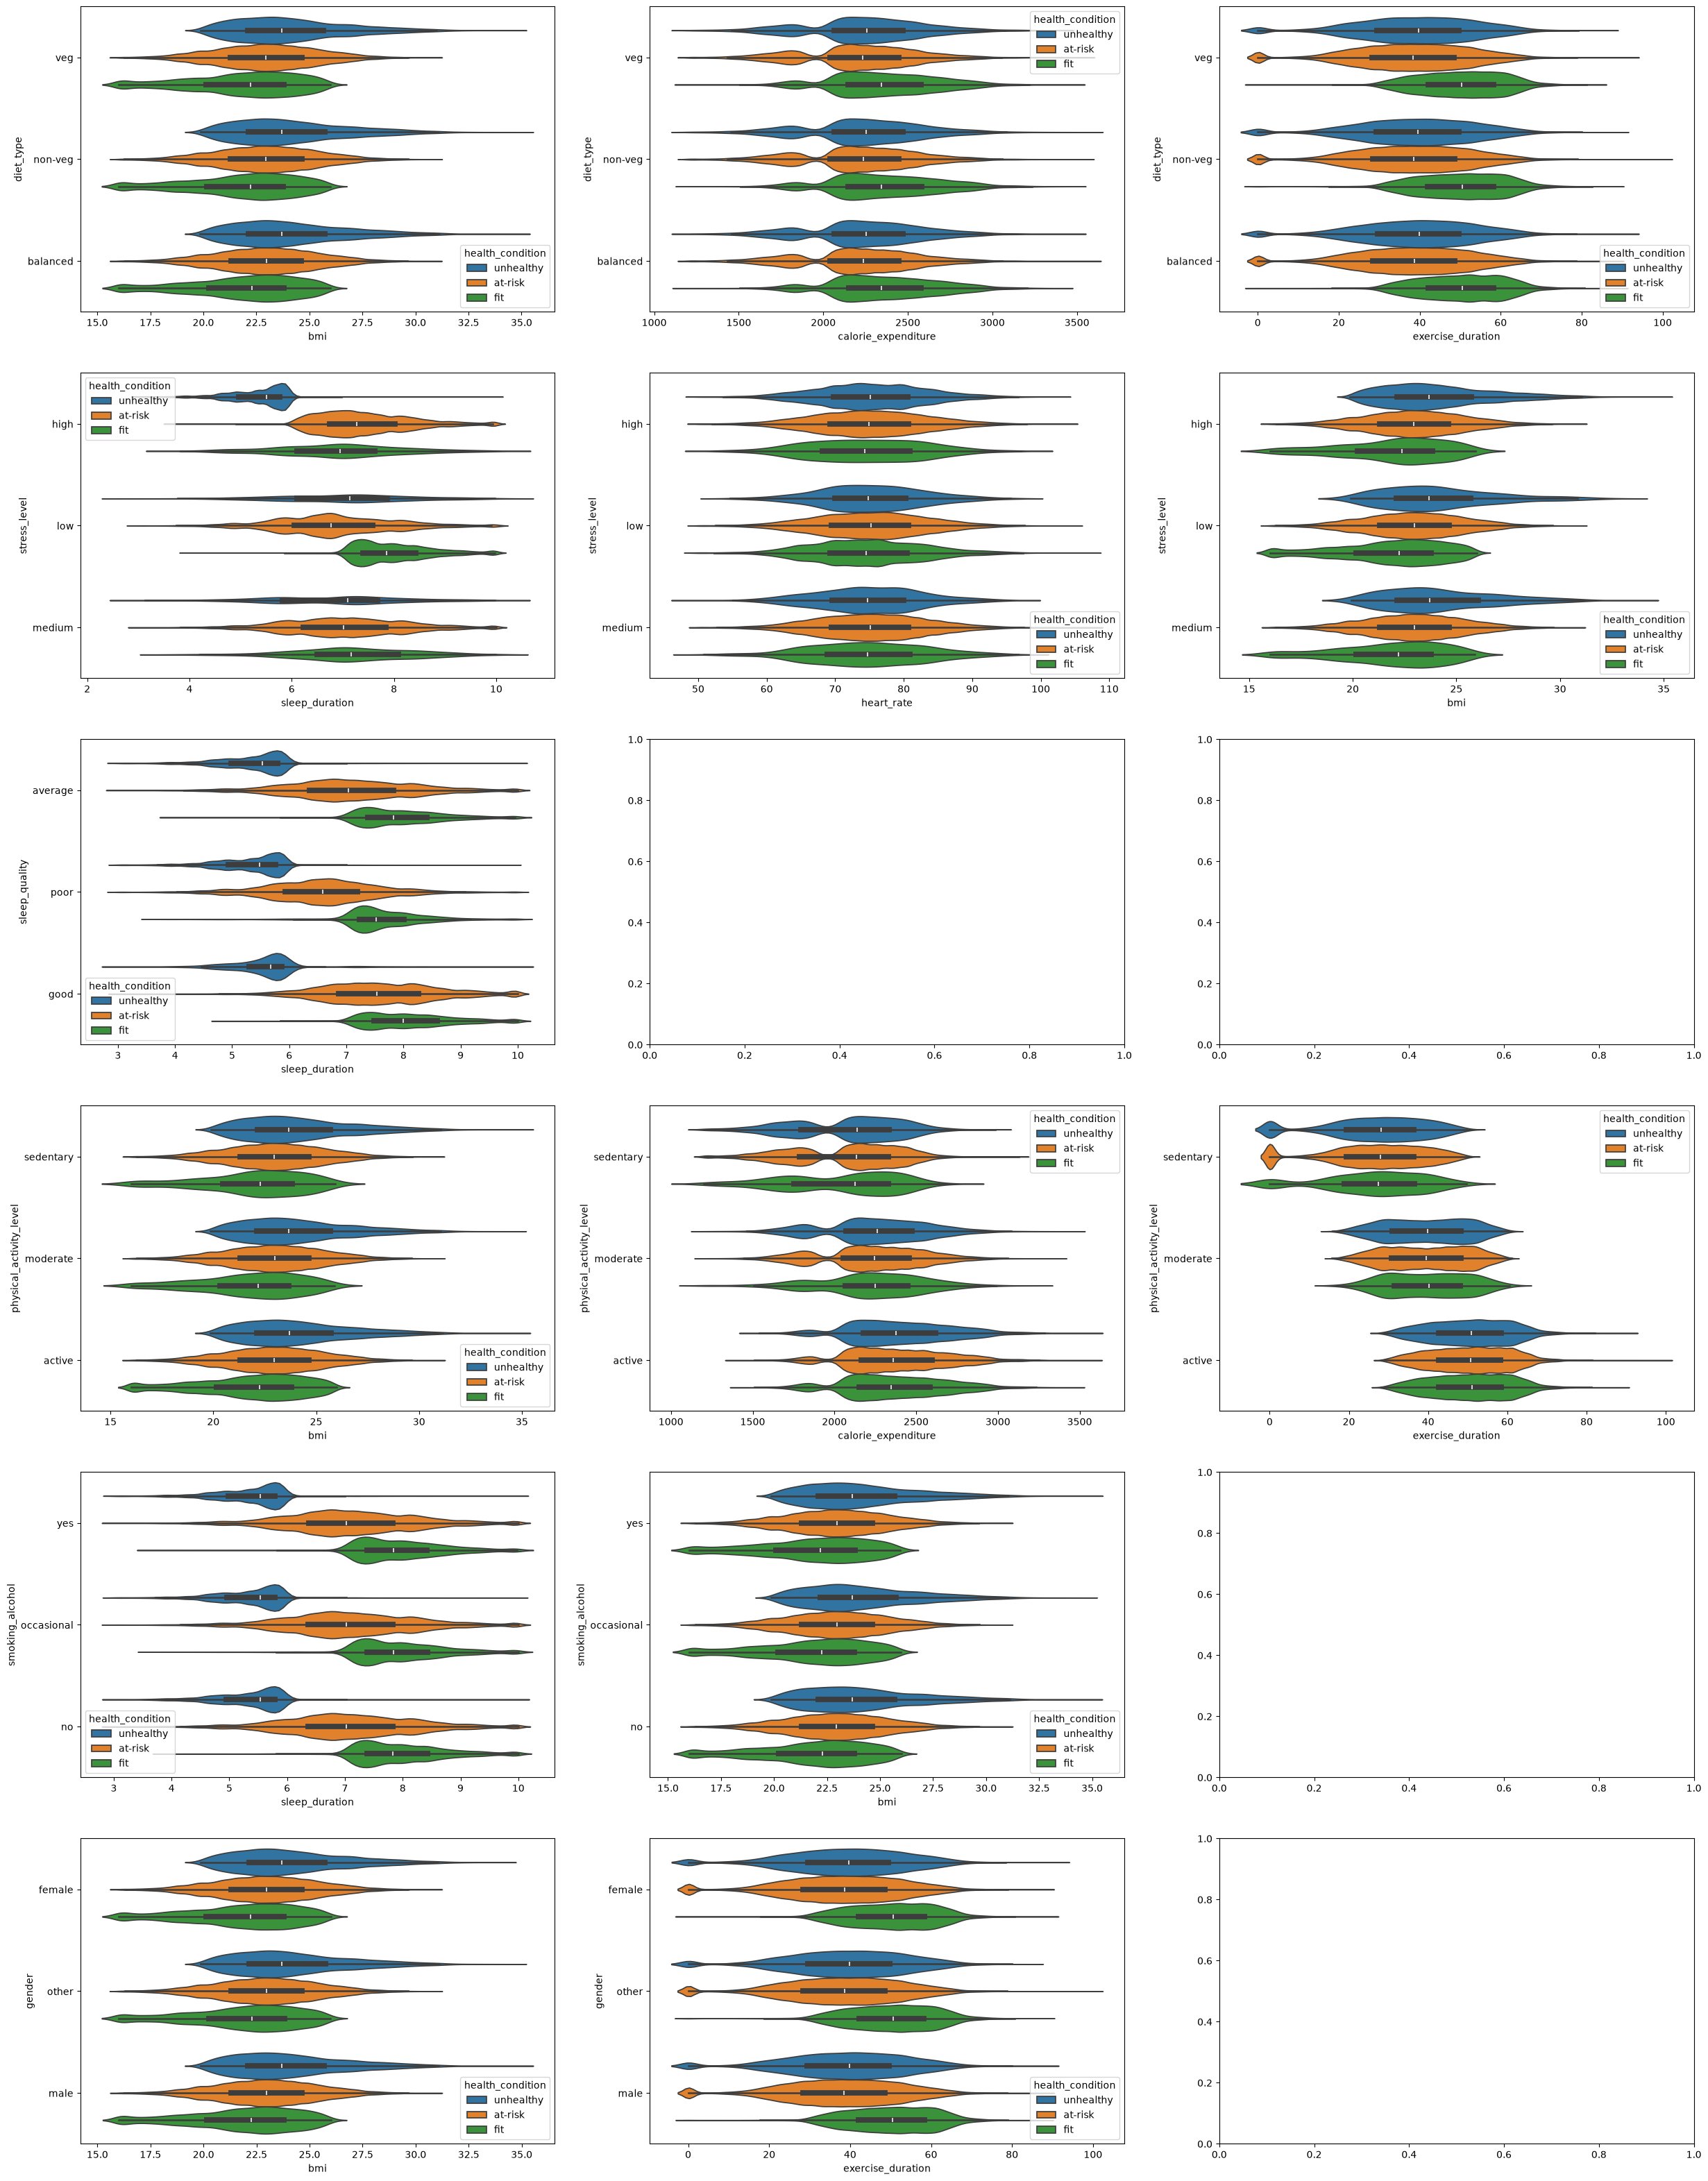

In [18]:
fig, axs = plt.subplots(figsize=(30,40),nrows=6, ncols=3)

sns.violinplot(df, x="bmi",y="diet_type",hue=target_column,ax=axs[0][0])
sns.violinplot(df, x="calorie_expenditure",y="diet_type",hue=target_column,ax=axs[0][1])
sns.violinplot(df, x="exercise_duration",y="diet_type",hue=target_column,ax=axs[0][2])

sns.violinplot(df, x="sleep_duration",y="stress_level",hue=target_column,ax=axs[1][0])
sns.violinplot(df, x="heart_rate",y="stress_level",hue=target_column,ax=axs[1][1])
sns.violinplot(df, x="bmi",y="stress_level",hue=target_column,ax=axs[1][2])

sns.violinplot(df, x="sleep_duration",y="sleep_quality",hue=target_column,ax=axs[2][0])

sns.violinplot(df, x="bmi",y="physical_activity_level",hue=target_column,ax=axs[3][0])
sns.violinplot(df, x="calorie_expenditure",y="physical_activity_level",hue=target_column,ax=axs[3][1])
sns.violinplot(df, x="exercise_duration",y="physical_activity_level",hue=target_column,ax=axs[3][2])

sns.violinplot(df, x="sleep_duration",y="smoking_alcohol",hue=target_column,ax=axs[4][0])
sns.violinplot(df, x="bmi",y="smoking_alcohol",hue=target_column,ax=axs[4][1])

sns.violinplot(df, x="bmi",y="gender",hue=target_column,ax=axs[5][0])
sns.violinplot(df, x="exercise_duration",y="gender",hue=target_column,ax=axs[5][1])

1. Stress level and sleep duration seems to show correlation with higher stress leading to lower sleep durations on average. 
2. Sleep quality and sleep duration also are correlation with lower sleep durations leading to poorer sleep quality.
3. Physical activity level and calorie expenditure are positively correlated.
4. Physical activity level and exercise duration are positively correlated.

**Check patterns across cross categorical features**

<Axes: xlabel='gender', ylabel='physical_activity_level'>

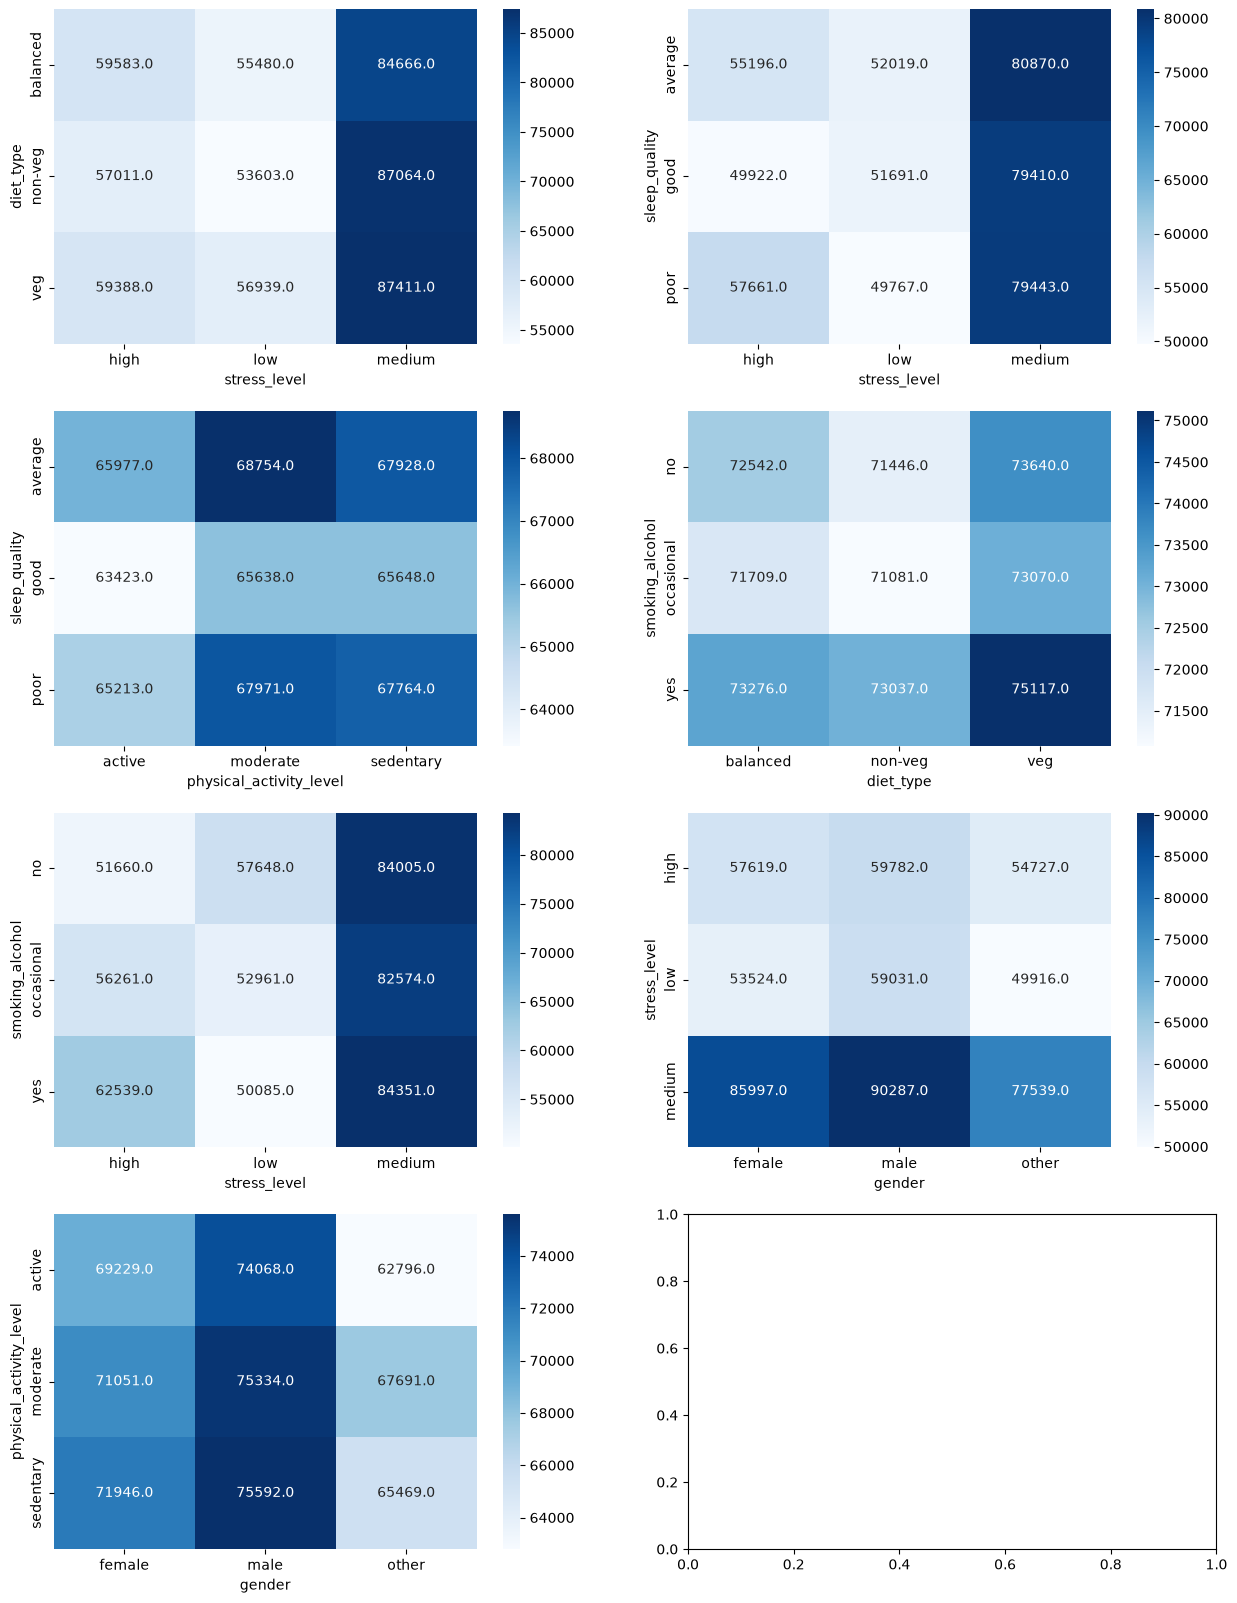

In [19]:
fig, axs = plt.subplots(figsize=(15,20),nrows=4, ncols=2)
cmap = sns.color_palette("Blues", as_cmap=True)
sns.heatmap(pd.crosstab(df["diet_type"], df["stress_level"]), annot=True, fmt=".1f",ax=axs[0][0],cmap=cmap)
sns.heatmap(pd.crosstab(df["sleep_quality"], df["stress_level"]), annot=True, fmt=".1f",ax=axs[0][1],cmap=cmap)
sns.heatmap(pd.crosstab(df["sleep_quality"], df["physical_activity_level"]), annot=True, fmt=".1f",ax=axs[1][0],cmap=cmap)

sns.heatmap(pd.crosstab(df["smoking_alcohol"], df["diet_type"]), annot=True, fmt=".1f",ax=axs[1][1],cmap=cmap)
sns.heatmap(pd.crosstab(df["smoking_alcohol"], df["stress_level"]), annot=True, fmt=".1f",ax=axs[2][0],cmap=cmap)

sns.heatmap(pd.crosstab(df["stress_level"], df["gender"]), annot=True, fmt=".1f",ax=axs[2][1],cmap=cmap)
sns.heatmap(pd.crosstab(df["physical_activity_level"], df["gender"]), annot=True, fmt=".1f",ax=axs[3][0],cmap=cmap)

1. Smokers and drinkers tend to have higher stress levels on average.

**Spearman Correlation Matrix (Numerical features)**

<Axes: >

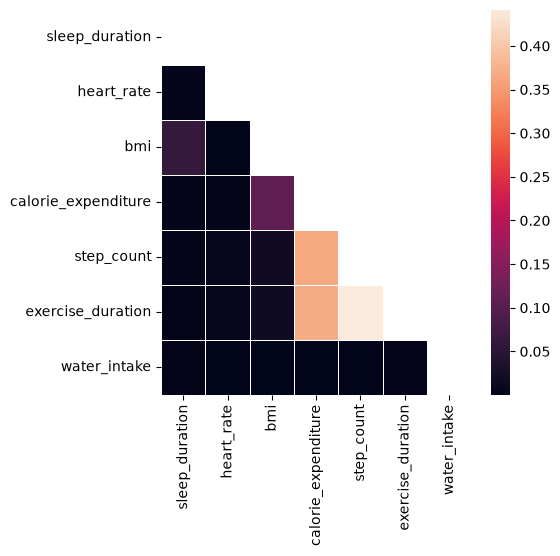

In [20]:
data_corr = df.copy()
data_corr.drop(['id', 'health_condition', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender'], axis=1, inplace=True)

corr = data_corr.corr(method='spearman').abs()
matrix_mask = np.triu(np.ones_like(corr)) # only show the upper triangular

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(corr, linewidths=.5, mask=matrix_mask)

Exercise features are strongly correlated with each other.

**Mutual information (Categorical features)**

C:\Users\abhin\AppData\Local\Temp\ipykernel_12464\1498707879.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mutual_info_values, y=no_nan.columns.values, palette="viridis")


Text(0.5, 1.0, 'Mutual Information vs. Target (Health Condition)')

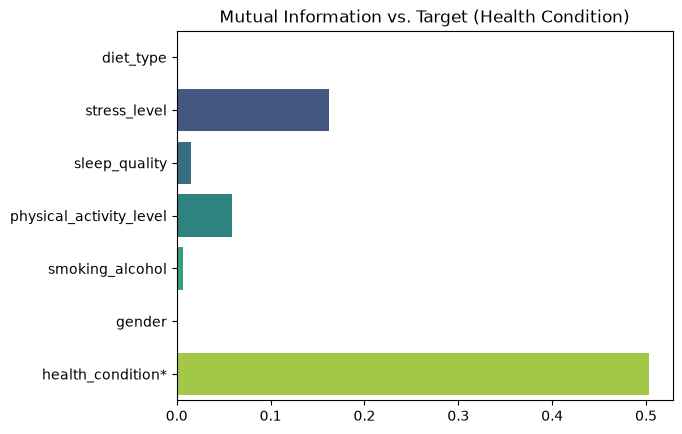

In [21]:
from sklearn.feature_selection import mutual_info_classif

data_corr = df.copy()
data_corr.drop(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake'], axis=1, inplace=True)

corr_no_nan = data_corr.dropna()

corr_no_nan['diet_type'] = corr_no_nan['diet_type'].replace({'veg':0, 'non-veg':2, 'balanced':1})
corr_no_nan['stress_level'] = corr_no_nan['stress_level'].replace({'low':0, 'medium':1, 'high':2})
corr_no_nan['sleep_quality'] = corr_no_nan['sleep_quality'].replace({'poor':0, 'average':1, 'good':2})

corr_no_nan['physical_activity_level'] = corr_no_nan['physical_activity_level'].replace({'sedentary':0, 'moderate':1, 'active':2})
corr_no_nan['smoking_alcohol'] = corr_no_nan['smoking_alcohol'].replace({'no':0, 'occasional':1, 'yes':2})
corr_no_nan['gender'] = corr_no_nan['gender'].replace({'other':0, 'female':1, 'male':2})

corr_no_nan[target_column] = corr_no_nan[target_column].replace({'unhealthy':0, 'at-risk':1, 'fit':2})

corr_no_nan['health_condition*'] = corr_no_nan[target_column] # a base stable column for comparison with other features

y = corr_no_nan[target_column].astype('int')
no_nan = corr_no_nan.drop(target_column, axis=1)

X = no_nan
mutual_info_values = mutual_info_classif(X, y, discrete_features=True)
sns.barplot(x=mutual_info_values, y=no_nan.columns.values, palette="viridis")
plt.title("Mutual Information vs. Target (Health Condition)")

Stress and physical activity do impact the condition of a student's health.

In [22]:
df['calorie_expenditure_per_step'] = df['calorie_expenditure'] / (df['step_count']+1)
df['step_speed'] = df['step_count'] / (df['exercise_duration']+1)
df['calorie_expenditure_per_min'] = df['calorie_expenditure'] / (df['exercise_duration']+1)
df['calorie_expenditure_per_bmi'] = df['calorie_expenditure'] / (df['bmi']+1)

<Axes: xlabel='calorie_expenditure_per_bmi', ylabel='Count'>

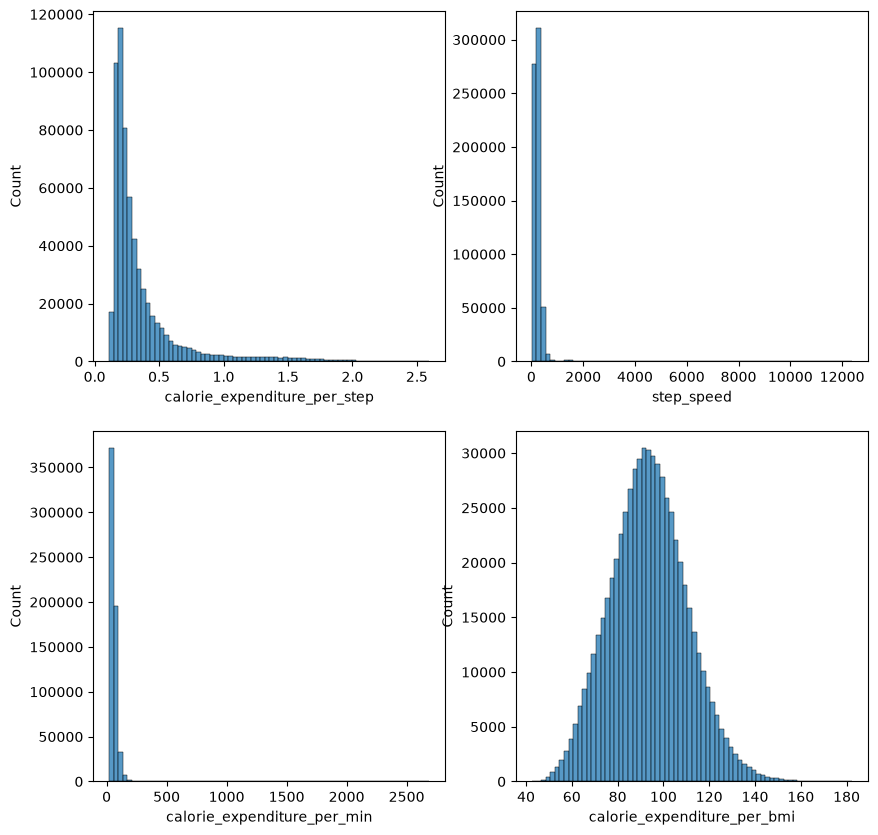

In [26]:
fig, axs = plt.subplots(figsize=(10,10),nrows=2, ncols=2)

sns.histplot(df, x="calorie_expenditure_per_step",ax=axs[0][0],bins=70, log_scale=False)
sns.histplot(df, x="step_speed",ax=axs[0][1],bins=70, log_scale=False)
sns.histplot(df, x="calorie_expenditure_per_min",ax=axs[1][0],bins=70, log_scale=False)
sns.histplot(df, x="calorie_expenditure_per_bmi",ax=axs[1][1],bins=70)